### LSTM (Long Short-Term Memory) 모델을 활용한 시장 예측
#### 📌 LSTM이란?
LSTM은 시계열 데이터에 특화된 딥러닝 모델입니다. 기존 RNN(Recurrent Neural Network)의 장기 의존성 문제를 해결하고, 과거의 중요한 정보를 장기적으로 기억할 수 있어 암호화폐와 같은 변동성이 큰 시장의 예측에 자주 사용됩니다.


#### 🔍 LSTM의 장점
- 장기 기억 능력: 과거 데이터의 장기적 패턴을 학습할 수 있습니다.
- 시계열 데이터에 강함: 가격 데이터와 같이 시간에 따라 변화하는 데이터를 잘 다룹니다

In [1]:
import pyupbit
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# 데이터 수집
df = pyupbit.get_ohlcv("KRW-BTC", interval="day", count=200)
# 'close' 가격만 사용
data = df['close'].values.reshape(-1, 1)

In [3]:
print(df)

                            open         high          low        close   
2024-10-23 09:00:00   92877000.0   93000000.0   90860000.0   92375000.0  \
2024-10-24 09:00:00   92375000.0   94699000.0   92080000.0   94077000.0   
2024-10-25 09:00:00   94077000.0   95143000.0   92432000.0   93762000.0   
2024-10-26 09:00:00   93762000.0   94298000.0   93297000.0   93993000.0   
2024-10-27 09:00:00   93993000.0   95120000.0   93900000.0   94819000.0   
...                          ...          ...          ...          ...   
2025-05-06 09:00:00  134890000.0  137800000.0  133061000.0  137400000.0   
2025-05-07 09:00:00  137351000.0  138282000.0  136050000.0  137660000.0   
2025-05-08 09:00:00  137680000.0  145000000.0  137402000.0  144780000.0   
2025-05-09 09:00:00  144688000.0  146200000.0  143500000.0  143720000.0   
2025-05-10 09:00:00  143726000.0  145315000.0  143646000.0  145124000.0   

                          volume         value  
2024-10-23 09:00:00  2169.770762  1.996658e+11  
2

In [4]:
print(data)

[[9.23750e+07]
 [9.40770e+07]
 [9.37620e+07]
 [9.39930e+07]
 [9.48190e+07]
 [9.74010e+07]
 [1.01305e+08]
 [1.00571e+08]
 [9.81120e+07]
 [9.72850e+07]
 [9.72050e+07]
 [9.58830e+07]
 [9.42890e+07]
 [9.61700e+07]
 [1.04085e+08]
 [1.04115e+08]
 [1.06843e+08]
 [1.06294e+08]
 [1.11440e+08]
 [1.24503e+08]
 [1.24967e+08]
 [1.28111e+08]
 [1.23572e+08]
 [1.28236e+08]
 [1.27071e+08]
 [1.26472e+08]
 [1.27142e+08]
 [1.29720e+08]
 [1.33180e+08]
 [1.37050e+08]
 [1.36879e+08]
 [1.36000e+08]
 [1.36096e+08]
 [1.29791e+08]
 [1.28783e+08]
 [1.32999e+08]
 [1.33138e+08]
 [1.34542e+08]
 [1.33701e+08]
 [1.33802e+08]
 [1.33535e+08]
 [1.33700e+08]
 [1.38760e+08]
 [1.37501e+08]
 [1.39340e+08]
 [1.38960e+08]
 [1.41005e+08]
 [1.38864e+08]
 [1.38205e+08]
 [1.43111e+08]
 [1.42757e+08]
 [1.44402e+08]
 [1.45927e+08]
 [1.49243e+08]
 [1.53403e+08]
 [1.55223e+08]
 [1.47754e+08]
 [1.47474e+08]
 [1.48138e+08]
 [1.47830e+08]
 [1.44800e+08]
 [1.42901e+08]
 [1.46831e+08]
 [1.48081e+08]
 [1.44076e+08]
 [1.42111e+08]
 [1.42302e

In [5]:
# 데이터 정규화 (0과 1 사이로 스케일링)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [6]:
# 시퀀스 데이터 생성 함수
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [7]:
# 시퀀스 길이 설정
seq_length = 10
X, y = create_sequences(scaled_data, seq_length)

In [8]:
# 데이터 분할 (80% 훈련, 20% 테스트)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [9]:
# LSTM 입력 형식 맞춤 (배치 크기, 시퀀스 길이, 특성 수)
X_train = X_train.reshape(X_train.shape[0], seq_length, 1)
X_test = X_test.reshape(X_test.shape[0], seq_length, 1)

In [10]:
# LSTM 모델 생성
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

In [11]:
# 모델 훈련
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
10/10 [==============================] - 2s 48ms/step - loss: 0.3143 - val_loss: 0.0669
Epoch 2/50
10/10 [==============================] - 0s 7ms/step - loss: 0.0389 - val_loss: 0.0215
Epoch 3/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0259 - val_loss: 0.0078
Epoch 4/50
10/10 [==============================] - 0s 7ms/step - loss: 0.0100 - val_loss: 0.0076
Epoch 5/50
10/10 [==============================] - 0s 7ms/step - loss: 0.0108 - val_loss: 0.0060
Epoch 6/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0091 - val_loss: 0.0072
Epoch 7/50
10/10 [==============================] - 0s 9ms/step - loss: 0.0085 - val_loss: 0.0058
Epoch 8/50
10/10 [==============================] - 0s 8ms/step - loss: 0.0084 - val_loss: 0.0058
Epoch 9/50
10/10 [==============================] - 0s 20ms/step - loss: 0.0082 - val_loss: 0.0058
Epoch 10/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0082 - val_loss: 0.0056
Epoch 11/50
10

In [12]:
# 예측
y_pred = model.predict(X_test)

2/2 [==============================] - 0s 3ms/step


In [13]:
# 예측값과 실제값을 원래 스케일로 되돌리기
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

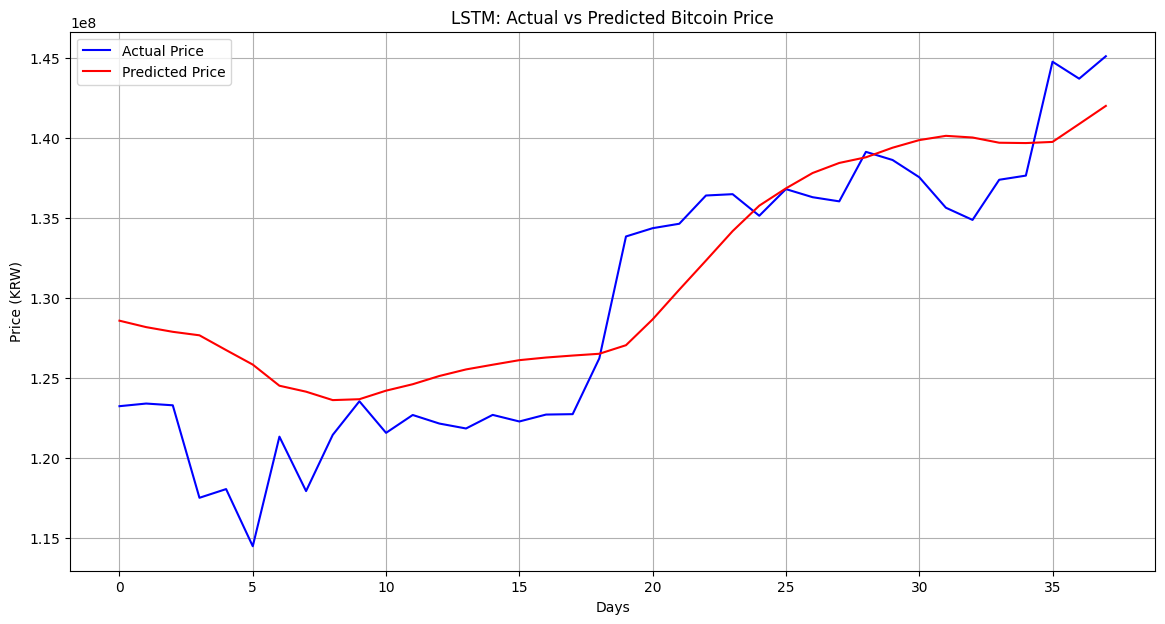

In [14]:
# 예측 결과 시각화
plt.figure(figsize=(14, 7))
plt.plot(y_test_inv, label='Actual Price', color='blue')
plt.plot(y_pred_inv, label='Predicted Price', color='red')
plt.title('LSTM: Actual vs Predicted Bitcoin Price')
plt.xlabel('Days')
plt.ylabel('Price (KRW)')
plt.legend()
plt.grid()
plt.show()